In [21]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [22]:
!pip install pandas numpy matplotlib seaborn xgboost joblib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [23]:
!pip install tensorflow streamlit pillow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
confusion_matrix,
classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
RandomForestClassifier,
GradientBoostingClassifier
)

from xgboost import XGBClassifier

import joblib

In [27]:
df = pd.read_csv("Titanic-Dataset.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch Embarked            Ticket     Fare Cabin  PassengerId  Pclass  \
0      0        S         A/5 21171   7.2500   NaN            1       3   
1      0        C          PC 17599  71.2833   C85            2       1   
2      0        S  STON/O2. 3101282   7.9250   NaN            3       3   
3      0        S            113803  53.1000  C123            4       1   
4      0        S            373450   8.0500   NaN            5       3   

   Survived  
0         0  
1         1  
2         1  
3         1  
4         0  
(8

Survived
0    549
1    342
Name: count, dtype: int64


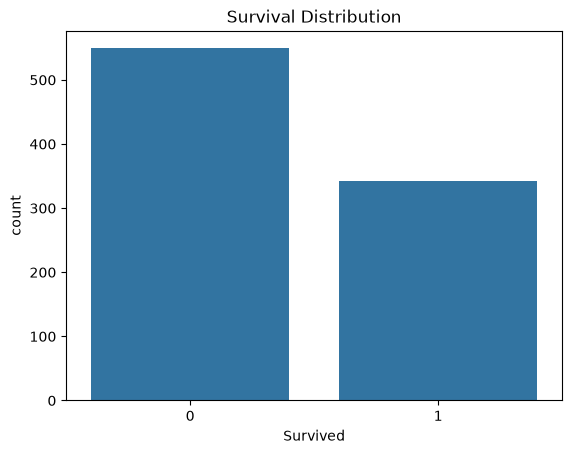

In [28]:
print(df["Survived"].value_counts())

sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

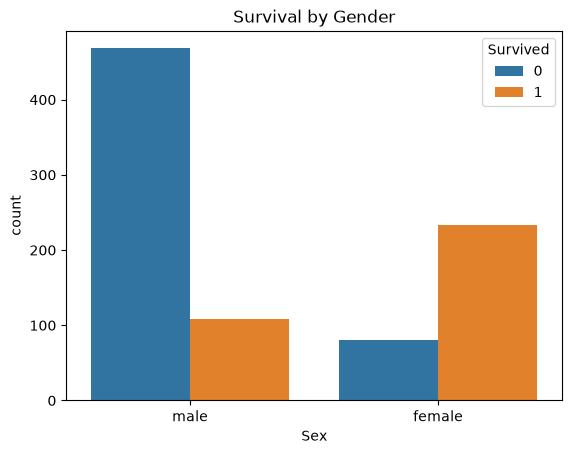

In [29]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

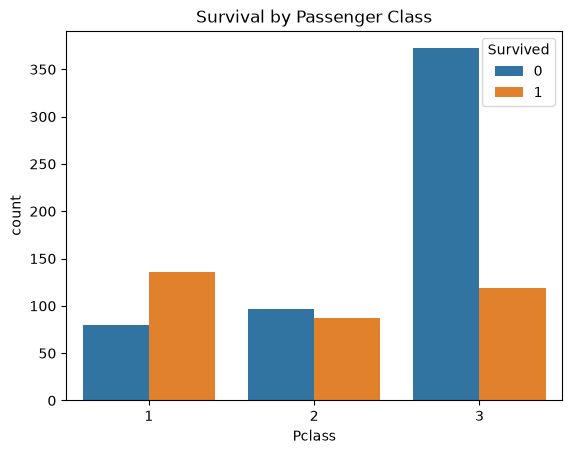

In [30]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

In [31]:
features = [
"Pclass",
"Sex",
"Age",
"SibSp",
"Parch",
"Fare",
"Embarked"
]

X = df[features]
y = df["Survived"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [33]:
numeric_features = [
"Pclass",
"Age",
"SibSp",
"Parch",
"Fare"
]

In [34]:
categorical_features = [
"Sex",
"Embarked"
]

In [35]:
numeric_transformer = Pipeline(
steps=[
("imputer",
SimpleImputer(strategy="median")),
("scaler",
StandardScaler())
]
)

categorical_transformer = Pipeline(
steps=[
("imputer",
SimpleImputer(strategy="most_frequent")),
("encoder",
OneHotEncoder(handle_unknown="ignore"))
]
)

preprocessor = ColumnTransformer(
transformers=[
("num",
numeric_transformer,
numeric_features),

("cat",
categorical_transformer,
categorical_features)
]
)

In [36]:
logistic_model = Pipeline(
steps=[
("preprocessor", preprocessor),
("model", LogisticRegression(
max_iter=1000
))
]
)

In [37]:
decision_tree = Pipeline(
steps=[
("preprocessor", preprocessor),
("model", DecisionTreeClassifier(
random_state=42,
max_depth=5
))
]
)

In [38]:
random_forest = Pipeline(
steps=[
("preprocessor", preprocessor),
("model", RandomForestClassifier(
n_estimators=300,
random_state=42
))
]
)

In [39]:
gradient_boosting = Pipeline(
steps=[
("preprocessor", preprocessor),
("model", GradientBoostingClassifier(
random_state=42
))
]
)

In [40]:
xgb_model = Pipeline(
steps=[
("preprocessor", preprocessor),
("model", XGBClassifier(
n_estimators=300,
max_depth=4,
learning_rate=0.05,
subsample=0.8,
colsample_bytree=0.8,
eval_metric="logloss",
random_state=42
))
]
)

In [41]:
ml_models = {
"Logistic Regression": logistic_model,
"Decision Tree": decision_tree,
"Random Forest": random_forest,
"Gradient Boosting": gradient_boosting,
"XGBoost": xgb_model
}

In [42]:
ml_results = []

for name, model in ml_models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    ml_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

ml_results_df = pd.DataFrame(ml_results)

print(ml_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.787709   0.762712  0.652174  0.703125  0.812846


In [43]:
print(
ml_results_df.sort_values(
by="F1 Score",
ascending=False
)
)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.787709   0.762712  0.652174  0.703125  0.812846
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101


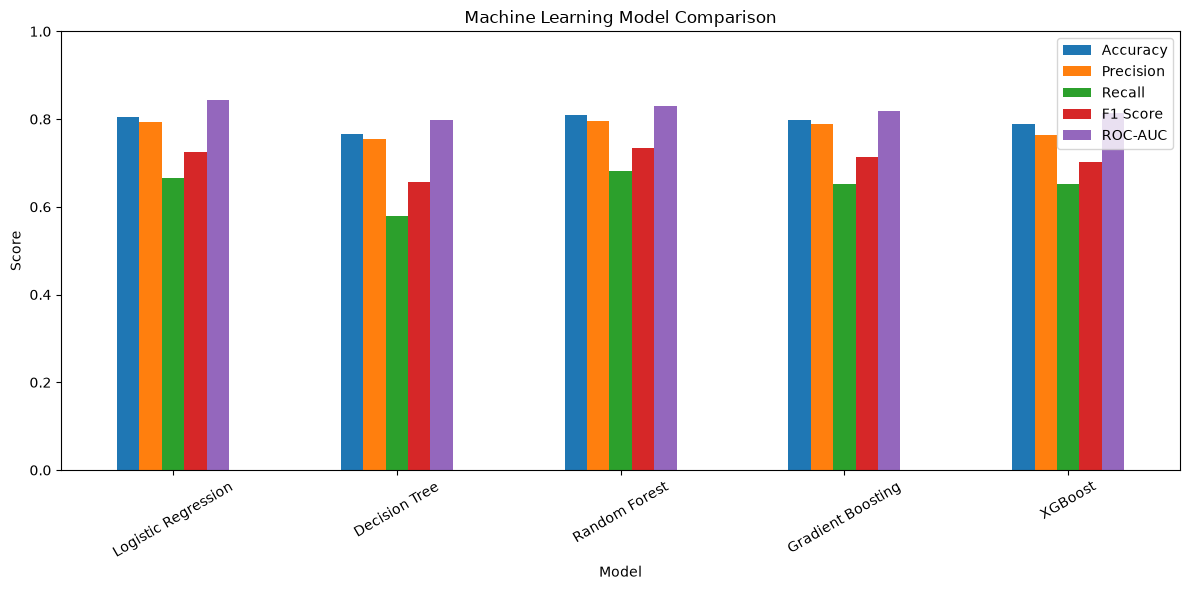

In [44]:
ml_results_df.set_index("Model")[
["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
kind="bar",
figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

dl_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

dl_categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

dl_preprocessor = ColumnTransformer([
    ("num", dl_numeric, numeric_features),
    ("cat", dl_categorical, categorical_features)
])

X_train_dl = dl_preprocessor.fit_transform(X_train)
X_test_dl = dl_preprocessor.transform(X_test)

print(X_train_dl.shape)

(712, 10)


In [46]:
import sys
print(sys.executable)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\python.exe


In [47]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [10]:
import sklearn

print(sklearn.__version__)


1.9.1


In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_model = Sequential([
    Dense(
        64,
        activation="relu",
        input_shape=(X_train_dl.shape[1],)
    ),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_history = ann_model.fit(
    X_train_dl,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.5290 - loss: 0.6902 - val_accuracy: 0.6503 - val_loss: 0.6455
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6819 - loss: 0.6190 - val_accuracy: 0.6783 - val_loss: 0.6017
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6960 - loss: 0.5827 - val_accuracy: 0.7273 - val_loss: 0.5590
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7346 - loss: 0.5612 - val_accuracy: 0.7622 - val_loss: 0.5113
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7680 - loss: 0.5151 - val_accuracy: 0.7552 - val_loss: 0.4819
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7715 - loss: 0.4872 - val_accuracy: 0.7972 - val_loss: 0.4624
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7926 - loss: 0.4741 - val_accuracy: 0.7972 - val_loss: 0.4554
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8032 - loss: 0.4575 - val_accuracy: 0.8112 - v

In [49]:
ann_prob = ann_model.predict(
    X_test_dl
).ravel()

ann_pred = (
    ann_prob >= 0.5
).astype(int)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [50]:
ann_results = {
    "Model": "ANN",
    "Accuracy": accuracy_score(
        y_test,
        ann_pred
    ),
    "Precision": precision_score(
        y_test,
        ann_pred
    ),
    "Recall": recall_score(
        y_test,
        ann_pred
    ),
    "F1 Score": f1_score(
        y_test,
        ann_pred
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        ann_prob
    )
}

print(ann_results)

{'Model': 'ANN', 'Accuracy': 0.7988826815642458, 'Precision': 0.8666666666666667, 'Recall': 0.5652173913043478, 'F1 Score': 0.6842105263157895, 'ROC-AUC': 0.860737812911726}


In [51]:
X_train_cnn = X_train_dl.reshape(
    X_train_dl.shape[0],
    X_train_dl.shape[1],
    1
)

X_test_cnn = X_test_dl.reshape(
    X_test_dl.shape[0],
    X_test_dl.shape[1],
    1
)

In [52]:
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten
)

cnn_model = Sequential([
    Conv1D(
        32,
        kernel_size=3,
        activation="relu",
        input_shape=(
            X_train_cnn.shape[1],
            1
        )
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        64,
        kernel_size=3,
        activation="relu"
    ),

    Flatten(),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        1,
        activation="sigmoid"
    )
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.6538 - loss: 0.6479 - val_accuracy: 0.7483 - val_loss: 0.5804
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7610 - loss: 0.5496 - val_accuracy: 0.8112 - val_loss: 0.4962
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7698 - loss: 0.4938 - val_accuracy: 0.7972 - val_loss: 0.4576
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7663 - loss: 0.4837 - val_accuracy: 0.8182 - val_loss: 0.4528
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7926 - loss: 0.4649 - val_accuracy: 0.8042 - val_loss: 0.4478
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7891 - loss: 0.4492 - val_accuracy: 0.8112 - val_loss: 0.4490
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7961 - loss: 0.4386 - val_accuracy: 0.8112 - val_loss: 0.4467
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8120 - loss: 0.4422 - val_accuracy: 0.8112 - v

In [53]:
cnn_prob = cnn_model.predict(
    X_test_cnn
).ravel()

cnn_pred = (
    cnn_prob >= 0.5
).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [54]:
cnn_results = {
    "Model": "1D CNN",
    "Accuracy": accuracy_score(
        y_test,
        cnn_pred
    ),
    "Precision": precision_score(
        y_test,
        cnn_pred
    ),
    "Recall": recall_score(
        y_test,
        cnn_pred
    ),
    "F1 Score": f1_score(
        y_test,
        cnn_pred
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        cnn_prob
    )
}

print(cnn_results)

{'Model': '1D CNN', 'Accuracy': 0.7486033519553073, 'Precision': 0.6714285714285714, 'Recall': 0.6811594202898551, 'F1 Score': 0.6762589928057554, 'ROC-AUC': 0.8355731225296442}


In [55]:
dl_results_df = pd.DataFrame([
    ann_results,
    cnn_results
])

all_results = pd.concat(
    [
        ml_results_df,
        dl_results_df
    ],
    ignore_index=True
)

In [56]:
all_results = all_results.sort_values(
    by="F1 Score",
    ascending=False
)

print(all_results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.787709   0.762712  0.652174  0.703125  0.812846
5                  ANN  0.798883   0.866667  0.565217  0.684211  0.860738
6               1D CNN  0.748603   0.671429  0.681159  0.676259  0.835573
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101


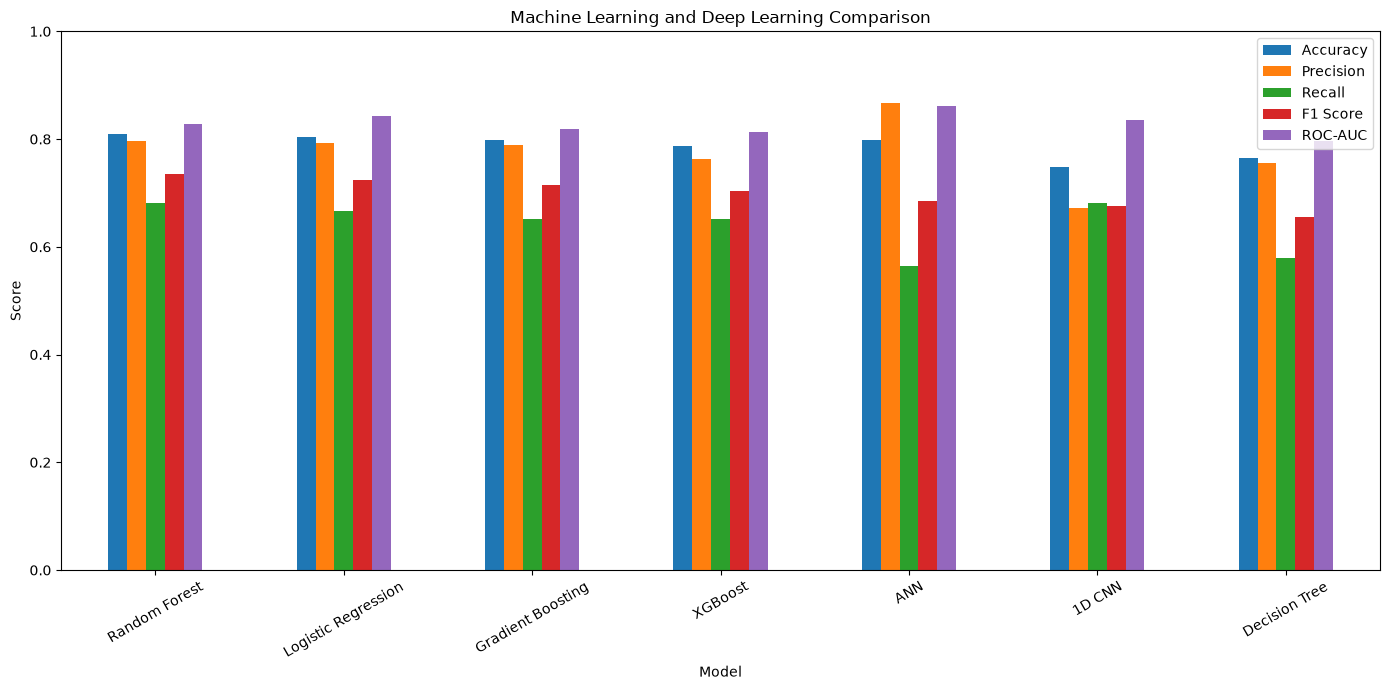

In [57]:
all_results.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Machine Learning and Deep Learning Comparison"
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [58]:
best_model_name = all_results.iloc[0]["Model"]

print(
    "Best model based on F1 Score:",
    best_model_name
)

Best model based on F1 Score: Random Forest


In [59]:
best_ml_model = ml_models[best_model_name]

joblib.dump(
    best_ml_model,
    "titanic_best_model.pkl"
)

['titanic_best_model.pkl']

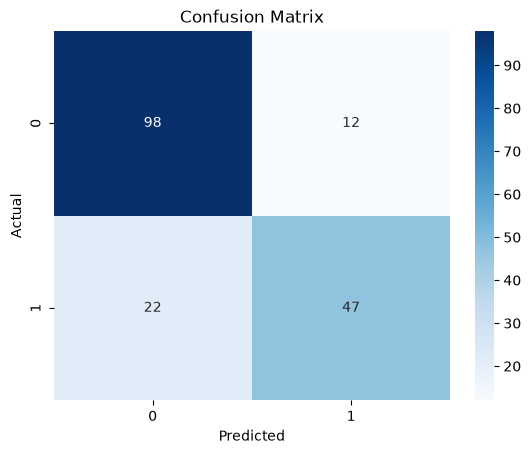

In [60]:
best_ml_model.fit(X_train, y_train)

y_pred = best_ml_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [61]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [62]:
rf = random_forest.named_steps["model"]

importance = rf.feature_importances_

print(importance)

[0.08724757 0.24386857 0.04653117 0.03852677 0.25748962 0.13645728
 0.15371693 0.01209837 0.00773332 0.01633041]
